Dean Hickman

Fall 2024

CS 251 / 252: Data Analysis and Visualization

Project 4: Principal Component Analysis

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pca

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 3: Analyzing the results of PCA

In this task, you will apply PCA to the Iris dataset and analyze properties of the PCA representation.

### 3a. Import Iris data

In the cell below:
- load in the Iris dataset into a pandas DataFrame.
- select all numeric headers (i.e. drop `species`).
- Print out the head (only showing the first 5 data samples).

You should see (with better formatting):

```
	sepal_length	sepal_width	petal_length	petal_width
0	5.1	3.5	1.4	0.2
1	4.9	3.0	1.4	0.2
2	4.7	3.2	1.3	0.2
3	4.6	3.1	1.5	0.2
4	5.0	3.6	1.4	0.2
```

In [11]:
iris_data = pd.read_csv('data/iris.csv')
iris_data = iris_data[iris_data.columns[:-1]]
print(iris_data.head(5))

   sepalLength  sepalWidth  petalLength  petalWidth
0          5.1         3.5          1.4         0.2
1          4.9         3.0          1.4         0.2
2          4.7         3.2          1.3         0.2
3          4.6         3.1          1.5         0.2
4          5.0         3.6          1.4         0.2


### 3b. Apply PCA to Iris

You should make the following plots:
1. Elbow plot of cumulative variance accounted for by first $k$ principal components.
2. Written description of your choice of number of PCs preserved and why.
3. Visualization (plot) of PCA projected data on 1st two PCs.

You should normalize the dataset when performing your PCA projection.

mins before normalization: [-1.54333 -1.05733 -2.758   -1.09933]
maxs before normalization: [2.05667 1.34267 3.142   1.30067]
data min/max -2.7580000000000005 / 3.142


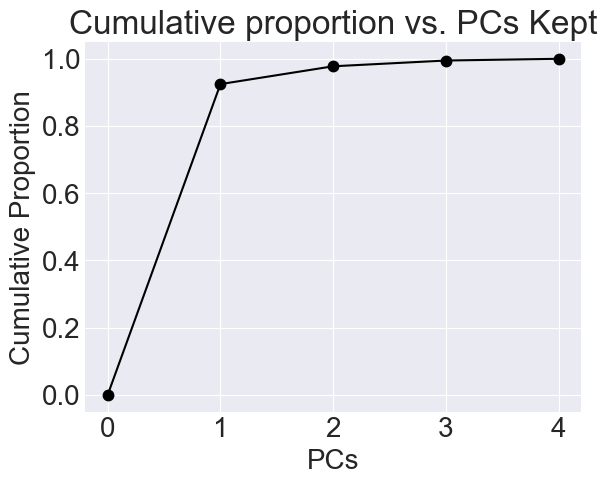

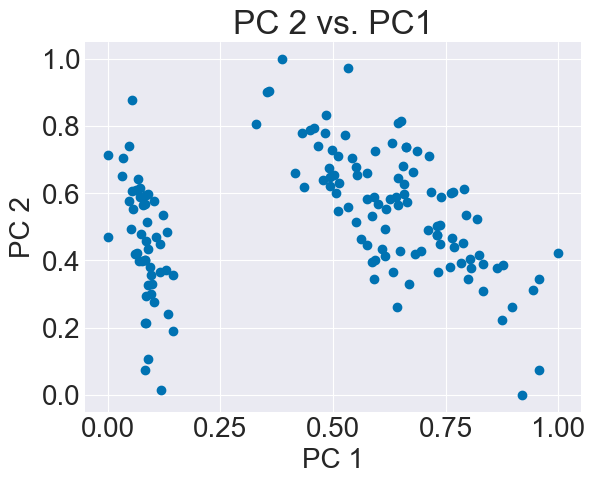

In [16]:
from data_transformations import normalize, center

iris_pca = pca.PCA(center(iris_data))
iris_pca.fit(iris_data.columns)
iris_pca.elbow_plot()
plt.show()

iris_proj = normalize(iris_pca.pca_project([0,1]))
plt.scatter(iris_proj[:,0], iris_proj[:,1])
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('PC 2 vs. PC1')
plt.show()



We will perserve two of the principal components because we can account for at 90% of the variance with just two. And we will select the ones that account for the largest proportions so those are the first two principle components. 

### 3c. Dropping different pairs of principal components

In the cell below, create a "high quality" 2x2 subplots grid of scatter plots that drops different consecutive PCs from the data, then project onto the remaining PCs.

The 2x2 plots should keep:
- (top-left) PCs [3, 4]
- (top-right) PCs [2, 3]
- (bottom-left) PCs [4, 1]
- (bottom-right) PCs [1, 2]

High quality means
- x and y axis label indicating the PC (e.g. PC1)
- title indicating the PCs shown in the plot

You may have to adjust the font/figure sizes to make things legible.

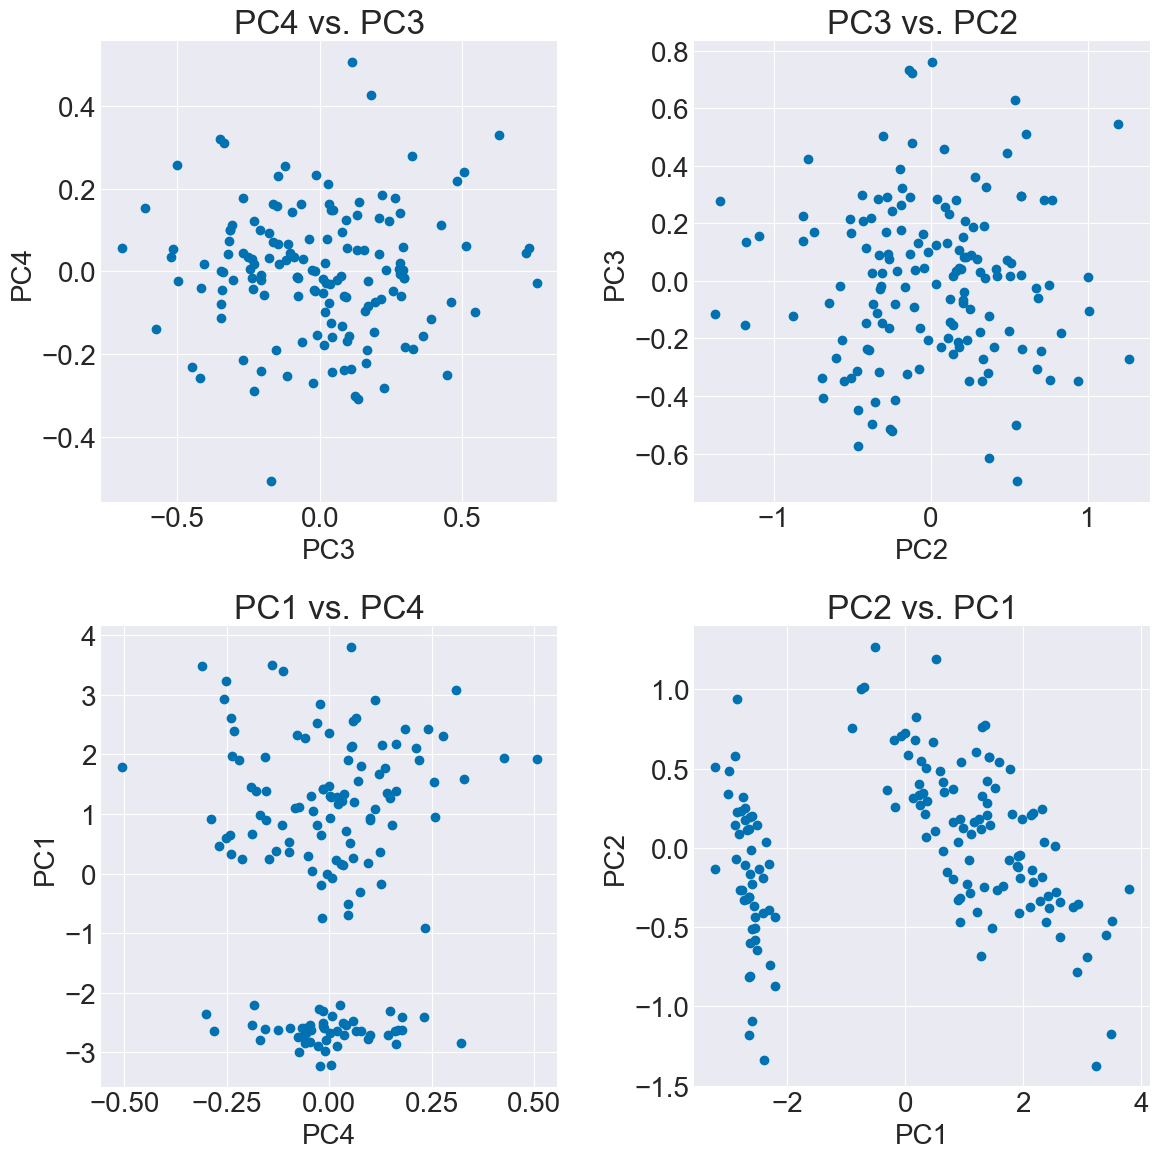

In [17]:
fig, axes = plt.subplots(2, 2, figsize = (12,12)) 
top_left = iris_pca.pca_project([2,3])
top_right = iris_pca.pca_project([1,2])
bottom_left = iris_pca.pca_project([3,0])
bottom_right = iris_pca.pca_project([0,1])

axes[0, 0].scatter(top_left[:, 0], top_left[:, 1])
axes[0, 0].set_title('PC4 vs. PC3')
axes[0, 0].set_xlabel('PC3')
axes[0, 0].set_ylabel('PC4')

axes[0, 1].scatter(top_right[:, 0], top_right[:, 1])
axes[0, 1].set_title('PC3 vs. PC2')
axes[0, 1].set_xlabel('PC2')
axes[0, 1].set_ylabel('PC3')

axes[1, 0].scatter(bottom_left[:, 0], bottom_left[:, 1])
axes[1, 0].set_title('PC1 vs. PC4')
axes[1, 0].set_xlabel('PC4')
axes[1, 0].set_ylabel('PC1')

axes[1, 1].scatter(bottom_right[:, 0], bottom_right[:, 1])
axes[1, 1].set_title('PC2 vs. PC1')
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

### 3d. Questions

**Question 8:** Interpret what the 2x2 grid of plots tells us about keeping different PCs.

**Answer 8:** The grid tells us that our assumption on what PCs to keep is in fact correct. PC1 plots have less variablity than PC4 and PC3 so it suggests that a large portion of variance is accounted for in that component and far less in compinents 4 and 3. PC 2 has a weaker cluster but still shows an important capturing of variance.

### 3e. Reconstruct data based on PCs

In `pca_cov.py`, implement `pca_then_project_back`, which projects the data to PCA space, keeping only the top $k$ PCs, then projects from PCA space back onto the original data space. Then in the cell below, create a scatter plot of the two data variables `sepal_length` (x), `sepal_width` (y) of the Iris data **without any normalization**.

[]

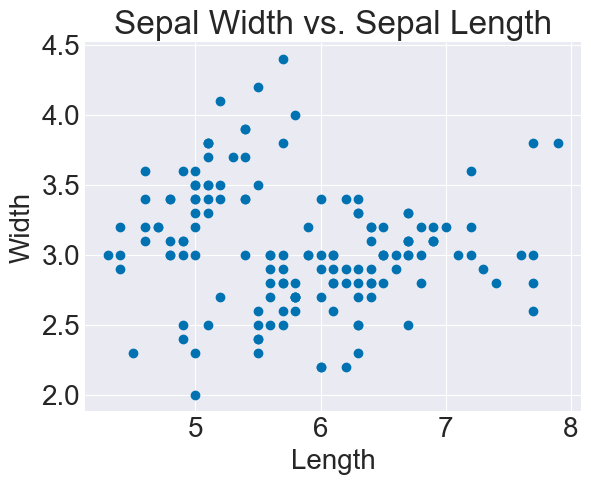

In [23]:
plt.scatter(iris_data[:,0], iris_data[:,1])
plt.xlabel("Length")
plt.ylabel("Width")
plt.title('Sepal Width vs. Sepal Length')
plt.plot()

In the cell below, apply PCA on the Iris dataset **without any normalization** and create a 2x2 grid of scatter plots showing the data reconstruction of the 1st two data variables (`sepal_length`, `sepal_width` — *these are what your axis labels should be*) when keeping the top 1, 2, 3, or 4 (all) principal components.

If everything goes well, if you keep all 4 PCs you should get the original dataset back (it should match your `sepal_length`, `sepal_width` plot created one cell above — including the data range and center).

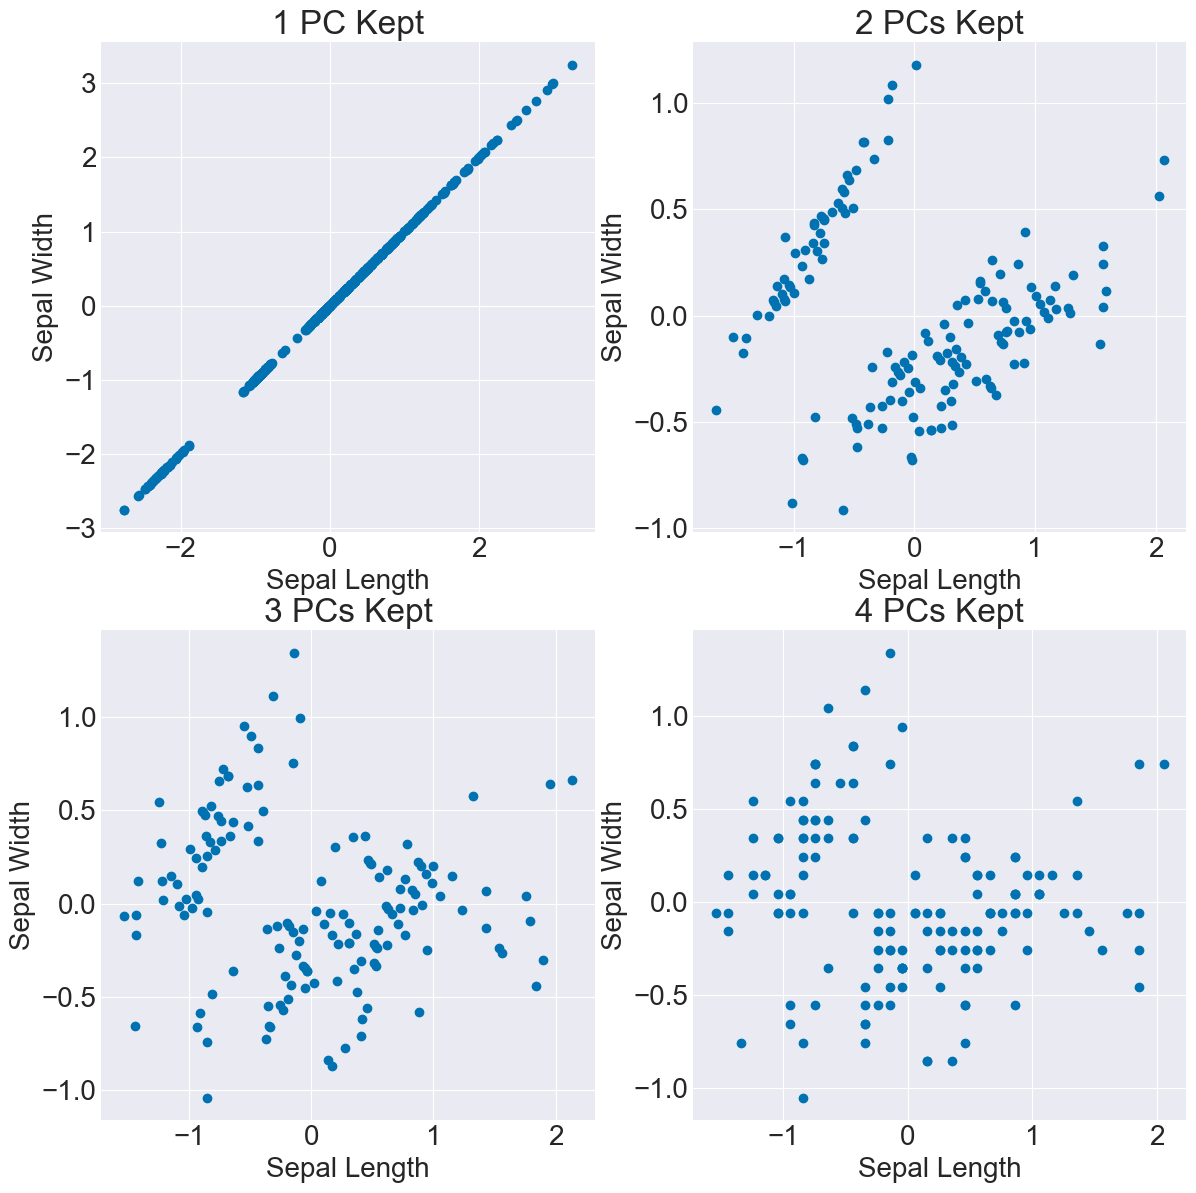

In [27]:
fig, axes = plt.subplots(2, 2, figsize = (14,14)) 
k_1 = iris_pca.pca_then_project_back(1)
k_2 = iris_pca.pca_then_project_back(2)
k_3 = iris_pca.pca_then_project_back(3)
k_4 = iris_pca.pca_then_project_back(4)

axes[0, 0].scatter(k_1, k_1)
axes[0, 0].set_title('1 PC Kept')
axes[0, 0].set_xlabel('Sepal Length')
axes[0, 0].set_ylabel('Sepal Width')

axes[0, 1].scatter(k_2[:, 0], k_2[:, 1])
axes[0, 1].set_title('2 PCs Kept')
axes[0, 1].set_xlabel('Sepal Length')
axes[0, 1].set_ylabel('Sepal Width')

axes[1, 0].scatter(k_3[:, 0], k_3[:, 1])
axes[1, 0].set_title('3 PCs Kept')
axes[1, 0].set_xlabel('Sepal Length')
axes[1, 0].set_ylabel('Sepal Width')

axes[1, 1].scatter(k_4[:, 0], k_4[:, 1])
axes[1, 1].set_title('4 PCs Kept')
axes[1, 1].set_xlabel('Sepal Length')
axes[1, 1].set_ylabel('Sepal Width')

plt.show()

### 3f. Questions

**Question 9:** How well does each of the re-projections preserve properties of the original data? Briefly interpret what the above 2x2 grid means.

**Answer 9:** The top left plot is not particularly useful since it is in one dimension but the other plots are useful. The thing to notice from this grid is that as we retain more and more of the principal components the better able we are at replicating the original dataset. This is because once we have all 4 PCs we can account for 100% of the variability in the data.

### 3g. Implement loading plot

To visualize how the top two principal components relate to original data variables, implement `loading_plot` in `pca.py`.

### 3h. Questions

**Question 10:** Call your `loading_plot` method to generate a loading plot of the Iris dataset. What do the loadings tell us what the first two PCs measure specifically, with respect to the original data variables?

**Question 11:** What specific correlations among original data variables do the loadings help us identity?

**Answer 10:** The loadings inicate that the first PC measures the petal category but specifically petalLength. The second PC measures the sepal category and is influenced strongly by both sepalWidth and sepalLength but the primary direction of variance is in the direction of sepalWidth.

**Answer 11:** It helps us identify that there is almost no correlation between petalLength and sepalLength, a negative correlation between petalLength and sepalWidth, petalWidth and petalLength is positively correlated as is sepalWidth and sepalLength (at a lower magnitude).

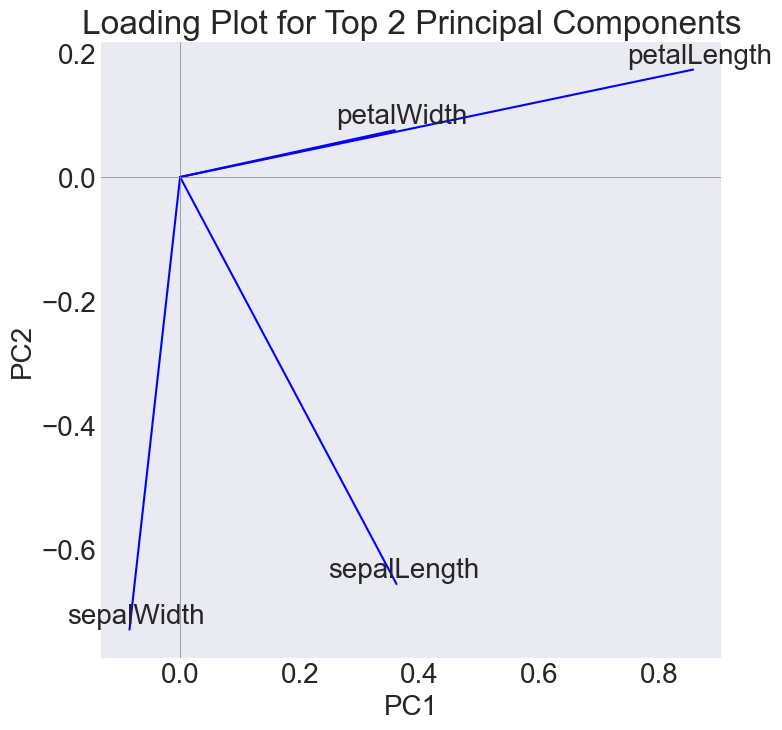

In [28]:
iris_pca.loading_plot()